In [ ]:
pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 12.8 MB/s eta 0:00:00


In [ ]:
# imports

In [ ]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

import optuna

In [ ]:
#LOAD DATA

In [ ]:
df = pd.read_csv("bengaluru_house_prices.csv")

In [ ]:
#DATA PREPROCESSING

In [ ]:
df = df.drop(['society'], axis=1)

In [ ]:
df['location'] = df['location'].fillna('Sarjapur Road')
df['bath'] = df['bath'].fillna(df['bath'].median())
df['balcony'] = df['balcony'].fillna(df['balcony'].median())
df = df.dropna(subset=['size', 'total_sqft'])

In [ ]:
df['bhk'] = df['size'].apply(lambda x: int(str(x).split(' ')[0]))
df = df.drop('size', axis=1)

In [ ]:
def convert_sqft(x):
    tokens = str(x).split('-')
    if len(tokens) == 2:
        try:
            return (float(tokens[0]) + float(tokens[1])) / 2
        except ValueError:
            return None
    try:
        return float(x)
    except ValueError:
        return None

df['total_sqft'] = df['total_sqft'].apply(convert_sqft)
df = df.dropna(subset=['total_sqft'])

In [ ]:
df['price_per_sqft'] = (df['price'] * 100000) / df['total_sqft']

In [ ]:
location_counts = df['location'].value_counts()

# Increase threshold from 10 to something much higher, e.g. 50
rare_locations = location_counts[location_counts <= 50]
df['location'] = df['location'].apply(lambda x: 'other' if x in rare_locations else x)

print("Unique locations remaining:", df['location'].nunique())

Unique locations remaining: 54


In [ ]:
df = df[~(df['total_sqft'] / df['bhk'] < 300)]

def remove_pps_outliers(data):
    out = pd.DataFrame()
    for key, subdf in data.groupby('location'):
        m = np.mean(subdf.price_per_sqft)
        st = np.std(subdf.price_per_sqft)
        reduced = subdf[(subdf.price_per_sqft > (m - st)) & (subdf.price_per_sqft <= (m + st))]
        out = pd.concat([out, reduced], ignore_index=True)
    return out

df = remove_pps_outliers(df)
df = df[df.bath < df.bhk + 2]


In [ ]:
df = df.drop('price_per_sqft', axis=1)

In [ ]:
df = pd.get_dummies(df, columns=['location', 'area_type', 'availability'], drop_first=True)

print("Final shape after preprocessing:", df.shape)

Final shape after preprocessing: (10724, 137)


In [ ]:
X = df.drop('price', axis=1)
y = df['price']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("X_train:", X_train.shape, " X_test:", X_test.shape)

X_train: (8579, 136)  X_test: (2145, 136)


In [ ]:
#BASELINE MODEL

In [ ]:
print("\n--- Training Baseline Model ---")

baseline_model = RandomForestRegressor(random_state=42)

start_time = time.time()
baseline_model.fit(X_train, y_train)
baseline_time = time.time() - start_time

y_pred = baseline_model.predict(X_test)

baseline_r2 = r2_score(y_test, y_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
baseline_mae = mean_absolute_error(y_test, y_pred)

print(f"Baseline R2   : {baseline_r2:.4f}")
print(f"Baseline RMSE : {baseline_rmse:.2f}")
print(f"Baseline Time : {baseline_time:.2f} sec")

results = {
    "Baseline": {
        "R2": baseline_r2, "RMSE": baseline_rmse, "MAE": baseline_mae,
        "Time": baseline_time, "Best_Params": "Default"
    }
}



--- Training Baseline Model ---
Baseline R2   : 0.8075
Baseline RMSE : 28.01
Baseline Time : 8.09 sec


In [ ]:
#GRID SEARCH

In [ ]:
grid_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, None]
}

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=grid_param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)

start_time = time.time()
grid_search.fit(X_train, y_train)
grid_time = time.time() - start_time

grid_pred = grid_search.best_estimator_.predict(X_test)
grid_r2 = r2_score(y_test, grid_pred)
grid_rmse = np.sqrt(mean_squared_error(y_test, grid_pred))
grid_mae = mean_absolute_error(y_test, grid_pred)

print(f"\nGrid Search Best Params : {grid_search.best_params_}")
print(f"Grid Search R2          : {grid_r2:.4f}")
print(f"Grid Search RMSE        : {grid_rmse:.2f}")
print(f"Grid Search Time        : {grid_time:.2f} seconds")

results["Grid Search"] = {
    "R2": grid_r2, "RMSE": grid_rmse, "MAE": grid_mae,
    "Time": grid_time, "Best_Params": grid_search.best_params_
}

Fitting 3 folds for each of 4 candidates, totalling 12 fits

Grid Search Best Params : {'max_depth': 10, 'n_estimators': 200}
Grid Search R2          : 0.8099
Grid Search RMSE        : 27.84
Grid Search Time        : 69.93 seconds


In [ ]:
#RANDOM SEARCH

In [ ]:
random_param_dist = {
    'n_estimators': [100, 150, 200, 250],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

random_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=random_param_dist,
    n_iter=10,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=2
)

start_time = time.time()
random_search.fit(X_train, y_train)
random_time = time.time() - start_time

random_pred = random_search.best_estimator_.predict(X_test)
random_r2 = r2_score(y_test, random_pred)
random_rmse = np.sqrt(mean_squared_error(y_test, random_pred))
random_mae = mean_absolute_error(y_test, random_pred)

print(f"\nRandom Search Best Params : {random_search.best_params_}")
print(f"Random Search R2          : {random_r2:.4f}")
print(f"Random Search Time        : {random_time:.2f} seconds")

results["Random Search"] = {
    "R2": random_r2, "RMSE": random_rmse, "MAE": random_mae,
    "Time": random_time, "Best_Params": random_search.best_params_
}

Fitting 3 folds for each of 10 candidates, totalling 30 fits

Random Search Best Params : {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_depth': 15}
Random Search R2          : 0.8154
Random Search Time        : 127.13 seconds


In [ ]:
#BAYESIAN OPTIMIZATION (OPTUNA)

In [ ]:
def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 100, 300)
    max_depth = trial.suggest_int('max_depth', 5, 20)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 5)

    model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=42,
        n_jobs=-1
    )

    score = cross_val_score(model, X_train, y_train, cv=3, scoring='r2').mean()
    return score

# Keep logging ON this time so you can see it working
optuna.logging.set_verbosity(optuna.logging.INFO)

study = optuna.create_study(direction='maximize')

start_time = time.time()
study.optimize(objective, n_trials=15, show_progress_bar=True)
optuna_time = time.time() - start_time

optuna_best_params = study.best_params
optuna_best_model = RandomForestRegressor(**optuna_best_params, random_state=42, n_jobs=-1)
optuna_best_model.fit(X_train, y_train)
optuna_pred = optuna_best_model.predict(X_test)

optuna_r2 = r2_score(y_test, optuna_pred)
optuna_rmse = np.sqrt(mean_squared_error(y_test, optuna_pred))
optuna_mae = mean_absolute_error(y_test, optuna_pred)

print(f"\nOptuna Best Params : {optuna_best_params}")
print(f"Optuna R2          : {optuna_r2:.4f}")
print(f"Optuna Time        : {optuna_time:.2f} seconds")

results["Bayesian Optimization (Optuna)"] = {
    "R2": optuna_r2, "RMSE": optuna_rmse, "MAE": optuna_mae,
    "Time": optuna_time, "Best_Params": optuna_best_params
}

[I 2026-07-18 07:08:49,871] A new study created in memory with name: no-name-7366a078-5d9b-4428-b895-22fdffcb6338


  0%|          | 0/15 [00:00<?, ?it/s]

[I 2026-07-18 07:09:00,816] Trial 0 finished with value: 0.6964147992033842 and parameters: {'n_estimators': 266, 'max_depth': 6, 'min_samples_split': 9, 'min_samples_leaf': 5}. Best is trial 0 with value: 0.6964147992033842.
[I 2026-07-18 07:09:18,405] Trial 1 finished with value: 0.7892276395306004 and parameters: {'n_estimators': 281, 'max_depth': 12, 'min_samples_split': 9, 'min_samples_leaf': 2}. Best is trial 1 with value: 0.7892276395306004.
[I 2026-07-18 07:09:27,006] Trial 2 finished with value: 0.7648346942044452 and parameters: {'n_estimators': 226, 'max_depth': 5, 'min_samples_split': 7, 'min_samples_leaf': 2}. Best is trial 1 with value: 0.7892276395306004.
[I 2026-07-18 07:09:36,207] Trial 3 finished with value: 0.7191529700348633 and parameters: {'n_estimators': 221, 'max_depth': 6, 'min_samples_split': 2, 'min_samples_leaf': 4}. Best is trial 1 with value: 0.7892276395306004.
[I 2026-07-18 07:09:51,620] Trial 4 finished with value: 0.7868694077691417 and parameters: {'n

In [ ]:
#FINAL COMPARISON TABLE

In [ ]:
comparison_df = pd.DataFrame(results).T
comparison_df = comparison_df[["R2", "RMSE", "MAE", "Time", "Best_Params"]]

print("\n===== FINAL COMPARISON: Baseline vs Grid vs Random vs Optuna =====")
print(comparison_df[["R2", "RMSE", "MAE", "Time"]])

comparison_df.to_csv("hpo_comparison_results.csv")
print("\nSaved to hpo_comparison_results.csv")


===== FINAL COMPARISON: Baseline vs Grid vs Random vs Optuna =====
                                      R2       RMSE        MAE        Time
Baseline                        0.807476  28.014874  16.114848    8.085777
Bayesian Optimization (Optuna)  0.812993  27.610572  16.831617  192.022768

Saved to hpo_comparison_results.csv


In [ ]:
#VISUALIZATIONS

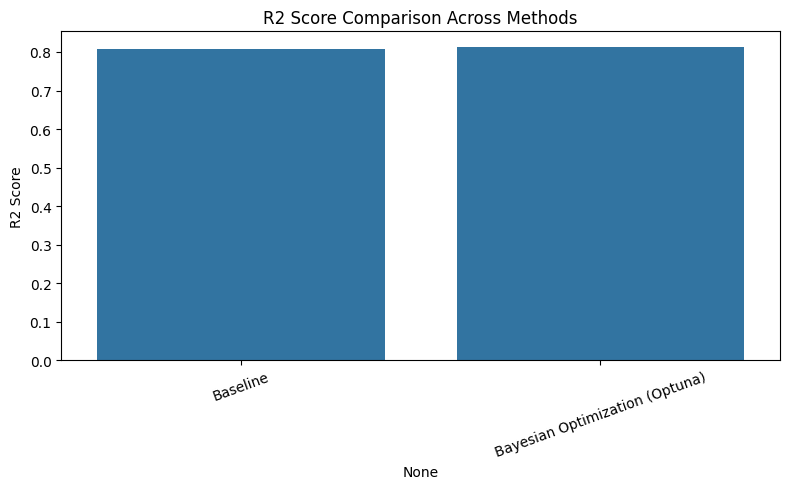

In [ ]:
# R2 Score comparison bar chart
plt.figure(figsize=(8, 5))
sns.barplot(x=comparison_df.index, y=comparison_df["R2"].astype(float))
plt.title("R2 Score Comparison Across Methods")
plt.ylabel("R2 Score")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("r2_comparison.png")
plt.show()

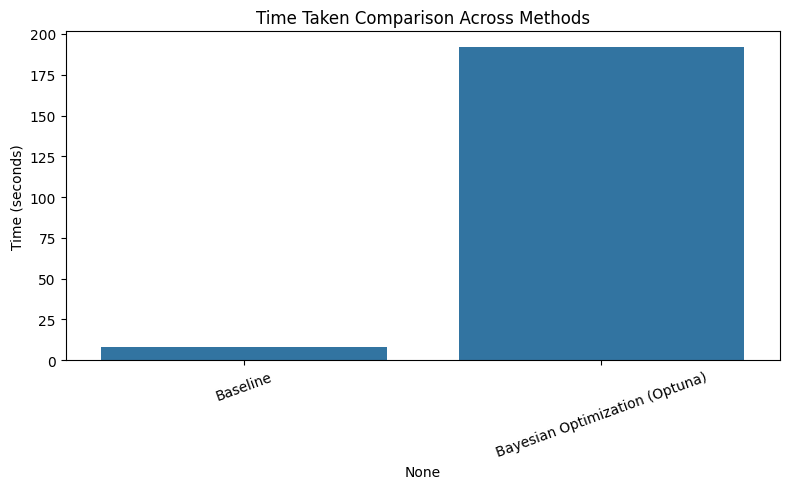

In [ ]:
# Time taken comparison bar chart
plt.figure(figsize=(8, 5))
sns.barplot(x=comparison_df.index, y=comparison_df["Time"].astype(float))
plt.title("Time Taken Comparison Across Methods")
plt.ylabel("Time (seconds)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("time_comparison.png")
plt.show()

/tmp/ipykernel_652/721243433.py:2: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(study)


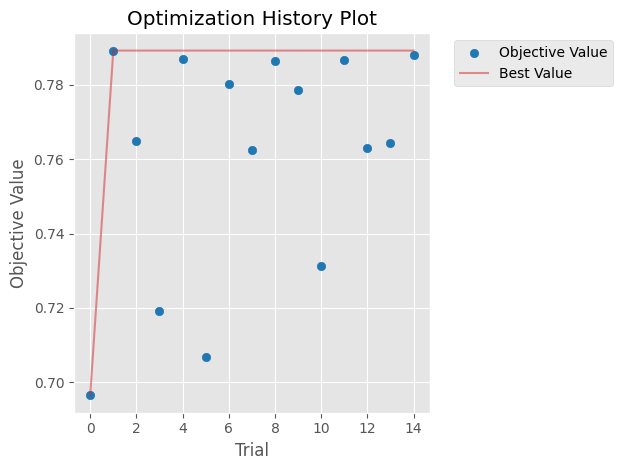

In [ ]:
#Optuna optimization history (score vs trail number)
optuna.visualization.matplotlib.plot_optimization_history(study)
plt.tight_layout()
plt.savefig("optuna_optimization_history.png")
plt.show()

/tmp/ipykernel_652/3498798700.py:2: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_param_importances(study)


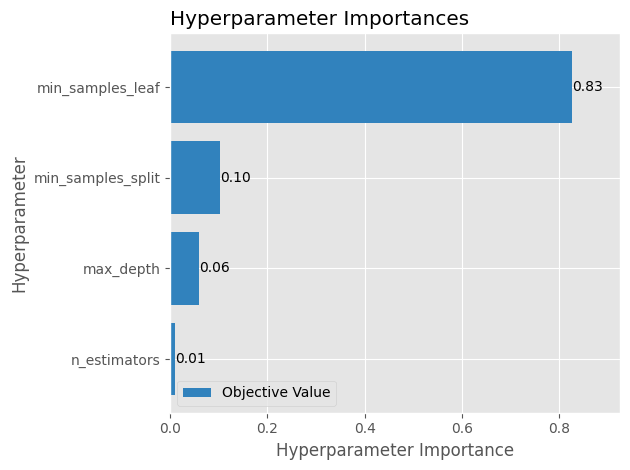

In [ ]:
# Optuna hyperparameter importance
optuna.visualization.matplotlib.plot_param_importances(study)
plt.tight_layout()
plt.savefig("optuna_param_importance.png")
plt.show()
